In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [ ]:
files = os.listdir("/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion")
print(files)

['utils.py', 'Readme file - Description of Experimental Tests.txt', 'Technical Information and Experimental Test Results for LG 18650HG2.pdf', '10degC', '0degC', '25degC', '40degC', 'n10degC', 'n20degC']


In [ ]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
file = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/25degC/549_Charge.csv"
with open(file, "r", errors="replace") as f:
    for i in range(1, 36):
        line = f.readline()
        print(f"{i}: {line.rstrip()}")

1: Measurement ID,549,,,,,,,,,,,,
2: Battery Name,LG HG2 18650_SN62A4,,,,,,,,,,,,
3: Battery Type,Li-ion,,,,,,,,,,,,
4: Circuit,Circuit001,,,,,,,,,,,,
5: Program,1744 - LG_HG2_NN_Char,,,,,,,,,,,,
6: Start Time,10/25/2018 4:08:59 AM,,,,,,,,,,,,
7: End Time,10/28/2018 11:02:52 AM,,,,,,,,,,,,
8: Test section,Charge,,,,,,,,,,,,
9: Comment,,,,,,,,,,,,,
10: OrderNo,,,,,,,,,,,,,
11: Producer, LG,,,,,,,,,,,,
12: Type, Li-ion,,,,,,,,,,,,
13: Nominal Voltage,3.7,,,,,,,,,,,,
14: Nominal Current,3,,,,,,,,,,,,
15: Nominal Capacity,3,,,,,,,,,,,,
16: Cells,1,,,,,,,,,,,,
17: Maximum Voltage,4.2,,,,,,,,,,,,
18: Gassing Voltage,0,,,,,,,,,,,,
19: Break Voltage,0,,,,,,,,,,,,
20: Charge Factor,0,,,,,,,,,,,,
21: Impedance,0.02,,,,,,,,,,,,
22: Cold Cranking Current,0,,,,,,,,,,,,
23: Energy Density,0,,,,,,,,,,,,
24: Comment,HG2 cell with 10AWG wire soldered  to cell,,,,,,,,,,,,
25: ,,,,,,,,,,,,,
26: ,,,,,,,,,,,,,
27: Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temper

In [ ]:
data_folder = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion"
csv_files = []
for root, dirs, files in os.walk(data_folder):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))
print("Total CSV files found:", len(csv_files))
for file in csv_files:
    print(file)

Total CSV files found: 208
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/571_Mixed8.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/571_Charge13.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/576_UDDS.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/567_Mixed1.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/567_Charge6.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/582_LA92.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/571_Mixed4.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/571_Cap_1C.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/576_Charge1.csv
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/10degC/571_Charge10.csv
/content/drive/MyDrive/BATTERY_SOC_PROJEC

In [ ]:
dataframes = {}
for file in csv_files:
    file_name = os.path.basename(file)
    try:
        with open(
            file,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:

            lines = f.readlines()
        header_index = None
        for i, line in enumerate(lines):
            line_lower = line.lower()
            if (
                "voltage" in line_lower
                and "current" in line_lower
                and "temperature" in line_lower
            ):
                header_index = i
                break
        if header_index is None:
            print("Measurement header not found:",file_name)
            continue
        from io import StringIO
        measurement_text = "".join(
            lines[header_index:]
        )

        df = pd.read_csv(
            StringIO(measurement_text)
        )
        if len(df) > 0:
            first_row = df.iloc[0].astype(str).str.strip()
            unit_values = first_row.str.lower().tolist()
            if (
                "v" in unit_values
                or "a" in unit_values
                or any("°c" in x for x in unit_values)
            ):
                df = df.iloc[1:].reset_index(drop=True)
        df.columns = (
            df.columns
            .astype(str)
            .str.strip())
        df = df.dropna(
            axis=1,
            how="all")
        dataframes[file_name] = df
        print("Loaded:",file_name,"| Header row:",header_index + 1,"| Rows:",df.shape[0],"| Columns:",df.shape[1])
    except Exception as e:
        print("Could not read:",file_name)
        print("Reason:",e)
print("LOADING SUMMARY")
print("Total CSV files found:",len(csv_files))
print("Successfully loaded:",len(dataframes))

Loaded: 571_Mixed8.csv | Header row: 29 | Rows: 81423 | Columns: 14
Loaded: 571_Charge13.csv | Header row: 29 | Rows: 207 | Columns: 14
Loaded: 576_UDDS.csv | Header row: 29 | Rows: 148899 | Columns: 14
Loaded: 567_Mixed1.csv | Header row: 29 | Rows: 72330 | Columns: 14
Loaded: 567_Charge6.csv | Header row: 29 | Rows: 208 | Columns: 14
Loaded: 582_LA92.csv | Header row: 29 | Rows: 90741 | Columns: 14
Loaded: 571_Mixed4.csv | Header row: 29 | Rows: 73930 | Columns: 14
Loaded: 571_Cap_1C.csv | Header row: 29 | Rows: 369 | Columns: 14
Loaded: 576_Charge1.csv | Header row: 29 | Rows: 131 | Columns: 14
Loaded: 571_Charge10.csv | Header row: 29 | Rows: 209 | Columns: 14
Loaded: 571_PausCycl.csv | Header row: 29 | Rows: 27832 | Columns: 14
Loaded: 571_Mixed6.csv | Header row: 29 | Rows: 73922 | Columns: 14
Loaded: 575_C20DisCh.csv | Header row: 29 | Rows: 2338 | Columns: 14
Loaded: 571_Mixed5.csv | Header row: 29 | Rows: 67175 | Columns: 14
Loaded: 567_Mixed2.csv | Header row: 29 | Rows: 7775

In [ ]:
print("\n" + "="*60)
print("COLUMN STRUCTURE ACROSS ALL CSV FILES")
print("="*60)
column_summary = []
for file_name, df in dataframes.items():
    column_summary.append({
        "File": file_name,
        "Columns": list(df.columns)
    })
column_summary_df = pd.DataFrame(column_summary)
print("\nTotal loaded files:", len(column_summary_df))
for _, row in column_summary_df.iterrows():
    print("\nFILE:", row["File"])
    print("COLUMNS:", row["Columns"])


COLUMN STRUCTURE ACROSS ALL CSV FILES

Total loaded files: 208

FILE: 571_Mixed8.csv
COLUMNS: ['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt']

FILE: 571_Charge13.csv
COLUMNS: ['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt']

FILE: 576_UDDS.csv
COLUMNS: ['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt']

FILE: 567_Mixed1.csv
COLUMNS: ['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt']

FILE: 567_Charge6.csv
COLUMNS: ['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature',

In [ ]:
file_summary = []
for file_name, df in dataframes.items():
    file_summary.append({
        "File Name": file_name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Column Names": ", ".join(
            df.columns.astype(str))})
file_summary_df = pd.DataFrame(
    file_summary
)
print("\nFirst few files:")
print(file_summary_df.head())
print("\nTotal measurement rows across all files:",file_summary_df["Rows"].sum())


First few files:
          File Name    Rows  Columns  \
0    571_Mixed8.csv   81423       14   
1  571_Charge13.csv     207       14   
2      576_UDDS.csv  148899       14   
3    567_Mixed1.csv   72330       14   
4   567_Charge6.csv     208       14   

                                        Column Names  
0  Time Stamp, Step, Status, Prog Time, Step Time...  
1  Time Stamp, Step, Status, Prog Time, Step Time...  
2  Time Stamp, Step, Status, Prog Time, Step Time...  
3  Time Stamp, Step, Status, Prog Time, Step Time...  
4  Time Stamp, Step, Status, Prog Time, Step Time...  

Total measurement rows across all files: 4955125


In [ ]:
combined_data = []
for file_name, df in dataframes.items():
    temp = df.copy()
    temp["File Name"] = file_name
    combined_data.append(temp)
if combined_data:
    data = pd.concat(
        combined_data,
        ignore_index=True,
        sort=False
    )
else:
    data = pd.DataFrame()
print("\nCombined dataset shape:")
print(data.shape)
print("\nCombined dataset columns:")
print(data.columns.tolist())


Combined dataset shape:
(4955125, 15)

Combined dataset columns:
['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt', 'File Name']


In [ ]:
data.columns = (
    data.columns
    .astype(str)
    .str.strip()
)

In [ ]:
def find_column(possible_names):
    for column in data.columns:
        column_clean = (
            str(column)
            .strip()
            .lower()
            .replace("_", "")
            .replace(" ", "")
        )
        for name in possible_names:
            name_clean = (
                name
                .lower()
                .replace("_", "")
                .replace(" ", "")
            )
            if column_clean == name_clean:
                return column
    return None
voltage_col = find_column(["Voltage"])
current_col = find_column(["Current"])
temperature_col = find_column(["Temperature"])
capacity_col = find_column(["Capacity"])
time_col = find_column(["Time Stamp","Time","Prog Time","Step Time"])
soc_col = find_column(["SOC","State of Charge"])
print("IMPORTANT COLUMN DETECTION")
print("Voltage column:", voltage_col)
print("Current column:", current_col)
print("Temperature column:", temperature_col)
print("Capacity column:", capacity_col)
print("Time column:", time_col)
print("SOC column:", soc_col)

IMPORTANT COLUMN DETECTION
Voltage column: Voltage
Current column: Current
Temperature column: Temperature
Capacity column: Capacity
Time column: Time Stamp
SOC column: None


In [ ]:
numeric_columns = [voltage_col,current_col,temperature_col,capacity_col,soc_col]
for column in numeric_columns:
    if column is not None:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce")

In [ ]:
missing_summary = pd.DataFrame({
    "Column": data.columns,
    "Missing Count": [
        data[column].isna().sum()
        for column in data.columns
        ],
    "Missing Percentage": [
        round(data[column].isna().mean() * 100,2)
        for column in data.columns]
})
print(missing_summary.to_string(index=False))

     Column  Missing Count  Missing Percentage
 Time Stamp            208                 0.0
       Step            208                 0.0
     Status            208                 0.0
  Prog Time            208                 0.0
  Step Time            208                 0.0
      Cycle            208                 0.0
Cycle Level            208                 0.0
  Procedure            208                 0.0
    Voltage            211                 0.0
    Current            211                 0.0
Temperature            211                 0.0
   Capacity            211                 0.0
     WhAccu              3                 0.0
        Cnt              4                 0.0
  File Name              0                 0.0


In [ ]:
duplicate_count = data.duplicated().sum()
print(
    "Total duplicate rows:",
    duplicate_count
)
if len(data) > 0:
    duplicate_percentage = (
        duplicate_count / len(data)
    ) * 100
else:
    duplicate_percentage = 0
print("Duplicate percentage:",round(duplicate_percentage,2),"%")

Total duplicate rows: 5876
Duplicate percentage: 0.12 %


In [ ]:
numeric_data = data.select_dtypes(include=np.number)
if not numeric_data.empty:
    print(numeric_data.describe().T)
else:
    print("No numeric columns found.")

                 count       mean        std       min       25%       50%  \
Step         4954917.0  41.202717  24.949429   1.00000  27.00000  40.00000   
Cycle        4954917.0   1.208757   1.149936   0.00000   1.00000   1.00000   
Cycle Level  4954917.0   0.874009   0.331839   0.00000   1.00000   1.00000   
Voltage      4954914.0   3.685101   0.295787   0.00000   3.47534   3.68937   
Current      4954914.0  -1.073297   2.355671 -18.09828  -2.13522  -0.29883   
Temperature  4954914.0   8.436578  17.975277 -22.50393  -8.51784   9.25395   
Capacity     4954914.0  -1.137625   0.767443  -2.78074  -1.72840  -1.14497   

                  75%         max  
Step         54.00000  9999.00000  
Cycle         1.00000    10.00000  
Cycle Level   1.00000     1.00000  
Voltage       3.92823     4.23990  
Current       0.00000     6.00472  
Temperature  24.08130    41.32730  
Capacity     -0.44733     2.81804  


In [ ]:
invalid_results = []
invalid_voltage = 0
invalid_current = 0
invalid_temperature = 0
invalid_capacity = 0
invalid_soc = 0
if voltage_col is not None:
    invalid_voltage = ((data[voltage_col] <= 0) |(data[voltage_col] > 10)).sum()
    invalid_results.append({"Parameter": "Voltage","Invalid Count": invalid_voltage,"Reason": "Voltage <= 0 or unusually high voltage" })
if current_col is not None:
    invalid_current = (~np.isfinite(data[current_col])).sum()
    invalid_results.append({"Parameter": "Current","Invalid Count": invalid_current,"Reason": "Infinite or non-finite current"})
if temperature_col is not None:
    invalid_temperature = (
        (data[temperature_col] < -50) |
        (data[temperature_col] > 100)
    ).sum()
    invalid_results.append({"Parameter": "Temperature","Invalid Count": invalid_temperature,"Reason": "Temperature outside broad physical range"})
if capacity_col is not None:
    invalid_capacity = (~np.isfinite(data[capacity_col])).sum()
    invalid_results.append({"Parameter": "Capacity","Invalid Count": invalid_capacity,"Reason": "Infinite or non-finite capacity" })
if soc_col is not None:
    invalid_soc = ( (data[soc_col] < 0) |(data[soc_col] > 100)).sum()
    invalid_results.append({"Parameter": "SOC","Invalid Count": invalid_soc,"Reason": "SOC outside 0-100%"})
invalid_results_df = pd.DataFrame(invalid_results)
if not invalid_results_df.empty:
    print(invalid_results_df.to_string(index=False))
else:
    print("No applicable numeric range checks available.")

  Parameter  Invalid Count                                   Reason
    Voltage              3   Voltage <= 0 or unusually high voltage
    Current            211           Infinite or non-finite current
Temperature              0 Temperature outside broad physical range
   Capacity            211          Infinite or non-finite capacity


In [ ]:
inf_results = []
for column in numeric_data.columns:
    inf_count = np.isinf(numeric_data[column]).sum()
    inf_results.append({"Column": column,"Infinite Values": inf_count})
inf_results_df = pd.DataFrame(
    inf_results
)
print(
    inf_results_df.to_string(
        index=False
    )
)

     Column  Infinite Values
       Step                0
      Cycle                0
Cycle Level                0
    Voltage                0
    Current                0
Temperature                0
   Capacity                0


In [ ]:
outlier_results = []
for column in numeric_data.columns:
    series = numeric_data[column].dropna()
    if len(series) < 4:
        outlier_results.append({"Column": column,"Outlier Count": 0,"Outlier Percentage": 0})
        continue
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (
        (series < lower_bound)
        |
        (series > upper_bound)
    )
    outlier_count = outliers.sum()
    outlier_percentage = (outlier_count /len(series)) * 100
    outlier_results.append({
        "Column": column,
        "Outlier Count": outlier_count,
        "Outlier Percentage":
        round(outlier_percentage,2)})
outlier_results_df = pd.DataFrame(
    outlier_results)
print(
    outlier_results_df.to_string(
        index=False
    ))

     Column  Outlier Count  Outlier Percentage
       Step             20                0.00
      Cycle        1222120               24.66
Cycle Level         624273               12.60
    Voltage             43                0.00
    Current         334288                6.75
Temperature              0                0.00
   Capacity          10627                0.21


In [ ]:
if soc_col is not None:
    print("SOC target column found:",soc_col)
    print("\nSOC statistics:")
    print(data[soc_col].describe())
    print("\nSOC missing values:",data[soc_col].isna().sum())
else:
    print("SOC column is not present in the raw measurement data.")
    print("SOC should not be invented at this stage.")
    print("It can be derived or prepared later according to the project methodology.")

SOC column is not present in the raw measurement data.
SOC should not be invented at this stage.
It can be derived or prepared later according to the project methodology.


In [ ]:
print("Available columns:")
for column in data.columns:
    print("-",column)
print("\nLeakage-related columns should be reviewed before ML.")
print("Future information or target-derived information should not be used as input features.")

Available columns:
- Time Stamp
- Step
- Status
- Prog Time
- Step Time
- Cycle
- Cycle Level
- Procedure
- Voltage
- Current
- Temperature
- Capacity
- WhAccu
- Cnt
- File Name

Leakage-related columns should be reviewed before ML.
Future information or target-derived information should not be used as input features.


In [ ]:
quality_results = []
for column in data.columns:
    missing_count = data[column].isna().sum()
    missing_percentage = (data[column].isna().mean()) * 100
    unique_values = (data[column].nunique(dropna=True))
    data_type = str(data[column].dtype)
    quality_results.append({
        "Column": column,
        "Data Type": data_type,
        "Missing Count": missing_count,
        "Missing %":round(missing_percentage,2),
        "Unique Values":unique_values})
quality_table = pd.DataFrame(quality_results)
print(quality_table.to_string(index=False))

     Column Data Type  Missing Count  Missing %  Unique Values
 Time Stamp    object            208        0.0         577393
       Step   float64            208        0.0             70
     Status    object            208        0.0              5
  Prog Time    object            208        0.0        4840467
  Step Time    object            208        0.0        3246062
      Cycle   float64            208        0.0             11
Cycle Level   float64            208        0.0              2
  Procedure    object            208        0.0              6
    Voltage   float64            211        0.0          15825
    Current   float64            211        0.0           8801
Temperature   float64            211        0.0            578
   Capacity   float64            211        0.0         265342
     WhAccu    object              3        0.0        1149704
        Cnt    object              4        0.0             39
  File Name    object              0        0.0        

In [ ]:
for _, row in quality_table.iterrows():
    column = row["Column"]
    missing_percentage = row["Missing %"]
    if missing_percentage > 0:

        print(
            f"{column}: "
            f"{missing_percentage}% missing values")
print("\nImportant:"
)
print("Missing values should be investigated before deciding whether to remove or impute them."
)


Important:
Missing values should be investigated before deciding whether to remove or impute them.


In [ ]:
cleaning_rules = [

    ("Metadata rows","Remove metadata rows before analysis"),
    ("Units row","Remove units row from measurement data"),
    ("Column names","Standardize column names"),
    ("Non-numeric values","Convert valid measurement values to numeric and flag invalid entries"),
    ("Missing values","Quantify and investigate before treatment"),
    ("Invalid measurements", "Flag values outside physically meaningful ranges"),
    ("Outliers","Flag statistical outliers and investigate before removal"),
    ("Target leakage","Remove future or target-derived information from input features"),
    ("Train/test contamination","Use cycle/session-aware splitting where appropriate"),
    ("Different file structures","Convert files into a common measurement schema")
]
cleaning_rules_df = pd.DataFrame(
    cleaning_rules,
    columns=["Issue","Proposed Action"]
)
print(
    cleaning_rules_df.to_string(
        index=False)
)

                    Issue                                                      Proposed Action
            Metadata rows                                 Remove metadata rows before analysis
                Units row                               Remove units row from measurement data
             Column names                                             Standardize column names
       Non-numeric values Convert valid measurement values to numeric and flag invalid entries
           Missing values                            Quantify and investigate before treatment
     Invalid measurements                     Flag values outside physically meaningful ranges
                 Outliers             Flag statistical outliers and investigate before removal
           Target leakage      Remove future or target-derived information from input features
 Train/test contamination                  Use cycle/session-aware splitting where appropriate
Different file structures                       Co

In [ ]:
print(" EXPECTED DATA QUALITY AFTER CLEANING")
print("Expected improvements:")
print("1. Consistent measurement structure across all CSV files")
print("2. Metadata separated from measurement data")
print("3. Correct numeric data types")
print("4. Missing values identified and treated appropriately")
print("5. Duplicate records identified")
print("6. Abnormal measurements flagged")
print("7. Potential leakage reduced")
print("8. Dataset prepared for later ML modelling")

 EXPECTED DATA QUALITY AFTER CLEANING
Expected improvements:
1. Consistent measurement structure across all CSV files
2. Metadata separated from measurement data
3. Correct numeric data types
4. Missing values identified and treated appropriately
5. Duplicate records identified
6. Abnormal measurements flagged
7. Potential leakage reduced
8. Dataset prepared for later ML modelling


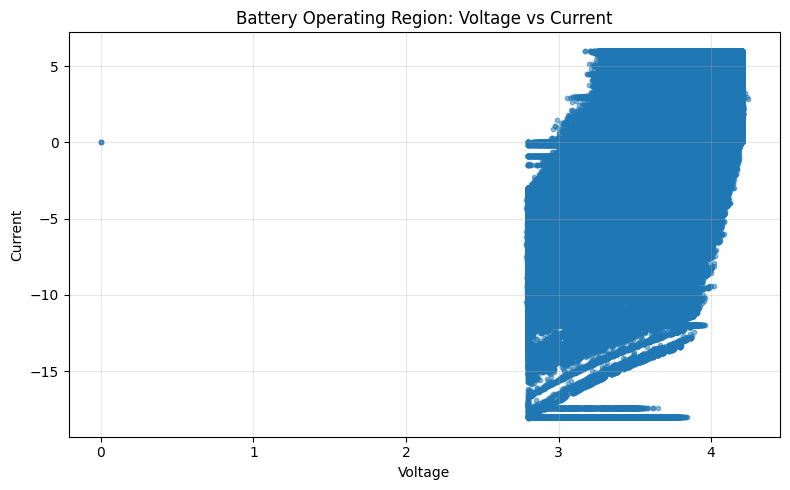

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
if (
    voltage_col is not None
    and current_col is not None
):
    plot_data = data[[voltage_col,current_col]].dropna()
    if len(plot_data) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter( plot_data[voltage_col],plot_data[current_col],alpha=0.5,s=10)
        plt.xlabel("Voltage")
        plt.ylabel("Current")
        plt.title("Battery Operating Region: Voltage vs Current")
        plt.grid(True,alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Graph skipped: No valid Voltage/Current data.")
else:
    print(
        "Graph skipped: Voltage or Current column not found.")

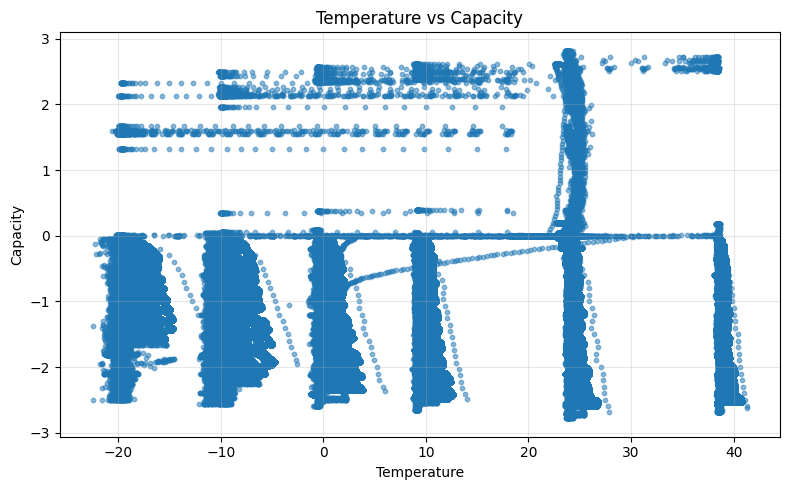

In [ ]:
if (
    temperature_col is not None
    and capacity_col is not None
):
    plot_data = data[[temperature_col,capacity_col]].dropna()
    if len(plot_data) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter(
            plot_data[temperature_col],
            plot_data[capacity_col],
            alpha=0.5,
            s=10)
        plt.xlabel("Temperature")
        plt.ylabel("Capacity")
        plt.title("Temperature vs Capacity")
        plt.grid(True,alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Graph skipped: No valid Temperature/Capacity data.")
else:
    print("Graph skipped: Temperature or Capacity column not found.")

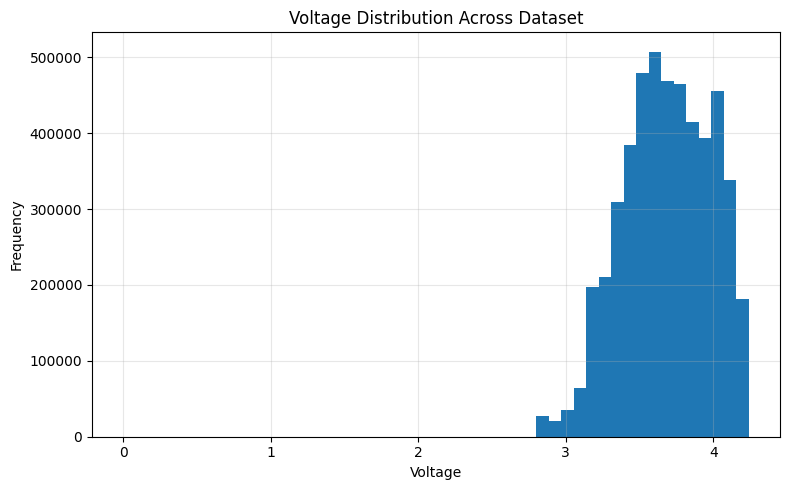

In [ ]:
if voltage_col is not None:
    voltage_data = data[voltage_col].dropna()
    if len(voltage_data) > 0:
        plt.figure(figsize=(8, 5))
        plt.hist(voltage_data,bins=50)
        plt.xlabel("Voltage")
        plt.ylabel("Frequency")
        plt.title("Voltage Distribution Across Dataset")
        plt.grid(True,alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Graph skipped: No valid voltage data.")
else:
    print("Graph skipped: Voltage column not found.")

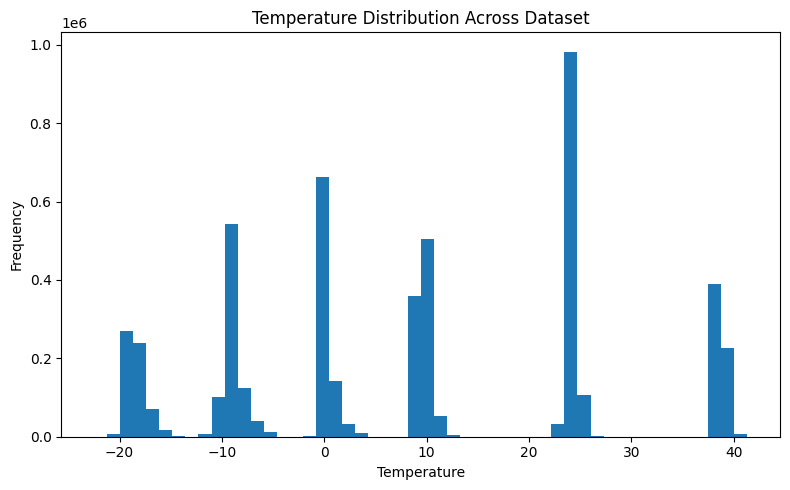

In [ ]:
if temperature_col is not None:
    temperature_data = data[
        temperature_col
    ].dropna()
    if len(temperature_data) > 0:
        plt.figure(figsize=(8, 5))
        plt.hist(temperature_data,bins=50)
        plt.xlabel("Temperature")
        plt.ylabel("Frequency")
        plt.title("Temperature Distribution Across Dataset")
        plt.grid(True,alpha=0.)
        plt.tight_layout()
        plt.show()

    else:
        print("Graph skipped: No valid temperature data.")
else:
    print("Graph skipped: Temperature column not found.")

In [ ]:
import matplotlib.pyplot as plt
if soc_col is not None:
    soc_data = data[soc_col].dropna()
    if len(soc_data) > 0:
        plt.figure(figsize=(8, 5))
        plt.hist(soc_data,bins=50)
        plt.xlabel("SOC (%)")
        plt.ylabel("Frequency")

        plt.title("SOC Distribution")
        plt.grid(True,lpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Graph skipped: SOC column exists but contains no valid data.")
else:
    print("SOC distribution graph skipped because SOC is not present in the raw dataset.")

SOC distribution graph skipped because SOC is not present in the raw dataset.


In [ ]:
dataset_path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/"

report_path = os.path.join(
    dataset_path,
    "Day_8_Data_Quality_Reports"
)
os.makedirs(
    report_path,
    exist_ok=True
)


file_summary_df.to_csv(
    os.path.join(report_path,"file_summary.csv"),index=False)


missing_summary.to_csv(
    os.path.join(report_path,"missing_values_report.csv"),index=False)

quality_table.to_csv(
    os.path.join(report_path,"feature_quality_report.csv"),index=False)
if not invalid_results_df.empty:
    invalid_results_df.to_csv(
        os.path.join(report_path,"invalid_values_report.csv"),index=False)

duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Duplicate Rows",
        "Duplicate Percentage"
    ],
    "Value": [len(data),duplicate_count,round(duplicate_percentage,2)]
})
duplicate_summary.to_csv(
    os.path.join(report_path,"duplicate_report.csv"),index=False)
outlier_results_df.to_csv(
    os.path.join(report_path,"outlier_report.csv"),index=False)
cleaning_rules_df.to_csv(
    os.path.join(report_path,"proposed_cleaning_rules.csv"),index=False)
print("\nReports saved successfully!")
print("\nReport folder:")
print(report_path)


Reports saved successfully!

Report folder:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/Day_8_Data_Quality_Reports


In [ ]:
print(" FINAL SUMMARY")
print( "\nTotal CSV files found:",len(csv_files))
print("Successfully loaded:",len(dataframes))
print("Total combined measurement rows:",len(data))
print("Total columns:",len(data.columns))
print("Duplicate rows:",duplicate_count)
print("Reports saved to:")
print(report_path)

 FINAL SUMMARY

Total CSV files found: 208
Successfully loaded: 208
Total combined measurement rows: 4955125
Total columns: 15
Duplicate rows: 5876
Reports saved to:
/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion/Day_8_Data_Quality_Reports
